# Necessary imports

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from warnings import filterwarnings

filterwarnings('ignore')
# plt.style.use('ggplot')
# plt.style.use('fivethirtyeight')

# Importing dataset
The data used is hourly power consumption data from PJM. Energy consumption has some unique characteristics. 

Pulling the PJM East which has data from 2002-2018 for the entire east region.

In [2]:
pjme = pd.read_csv('../data/PJME_hourly.csv', index_col=[0], parse_dates=[0])
pjme

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


# Data pre-processing

## Visualization

<Axes: title={'center': 'PJME Mega watts consumption'}, xlabel='Datetime', ylabel='Energy in mega-watts'>

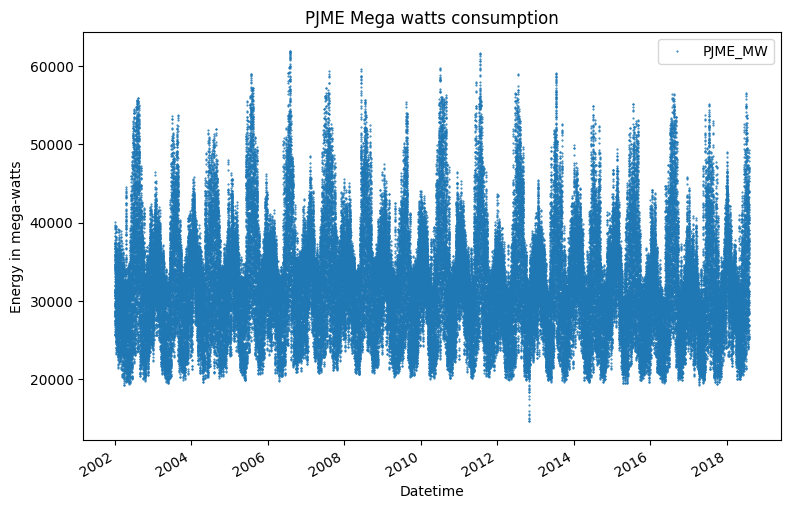

In [3]:
color_palette = sns.color_palette()
pjme.plot(
    figsize=(9,6),
    style='.',
    title='PJME Mega watts consumption',
    ms=1,
    color=color_palette[0],
    ylabel='Energy in mega-watts'
)

## Seasonal decomposition

<Figure size 900x600 with 0 Axes>

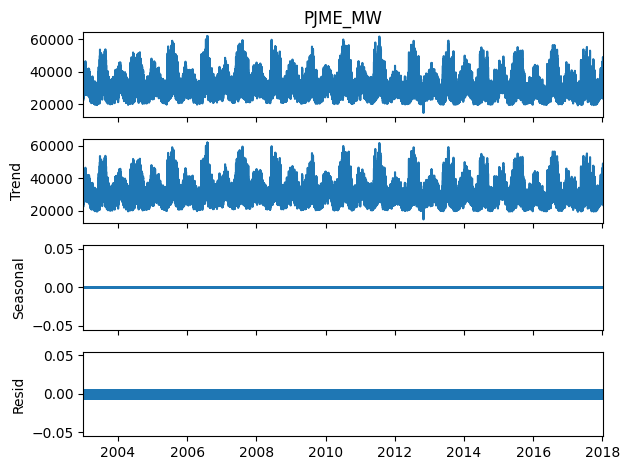

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed_mega_watts = seasonal_decompose(x=pjme['PJME_MW'], period=1, model='additive')
plt.figure(figsize=(9,6))
decomposed_mega_watts.plot()
plt.show()

## Timeseries features

In [5]:
from pandas.api.types import CategoricalDtype

category_types = CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

def create_features(
    df: pd.DataFrame,
    label=None
) -> tuple[pd.DataFrame, pd.DataFrame] | pd.DataFrame:
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(category_types)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])
    X = df[['hour','dayofweek','quarter','month','year','dayofyear','dayofmonth','weekofyear','weekday','season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(pjme, label='PJME_MW')
features_and_target: pd.DataFrame = pd.concat([X, y], axis=1)

features_and_target

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


In [6]:
features_and_target.isna(), features_and_target.shape

(                      hour  dayofweek  quarter  month   year  dayofyear  \
 Datetime                                                                  
 2002-12-31 01:00:00  False      False    False  False  False      False   
 2002-12-31 02:00:00  False      False    False  False  False      False   
 2002-12-31 03:00:00  False      False    False  False  False      False   
 2002-12-31 04:00:00  False      False    False  False  False      False   
 2002-12-31 05:00:00  False      False    False  False  False      False   
 ...                    ...        ...      ...    ...    ...        ...   
 2018-01-01 20:00:00  False      False    False  False  False      False   
 2018-01-01 21:00:00  False      False    False  False  False      False   
 2018-01-01 22:00:00  False      False    False  False  False      False   
 2018-01-01 23:00:00  False      False    False  False  False      False   
 2018-01-02 00:00:00  False      False    False  False  False      False   
 
          

## Analyzing the power usage

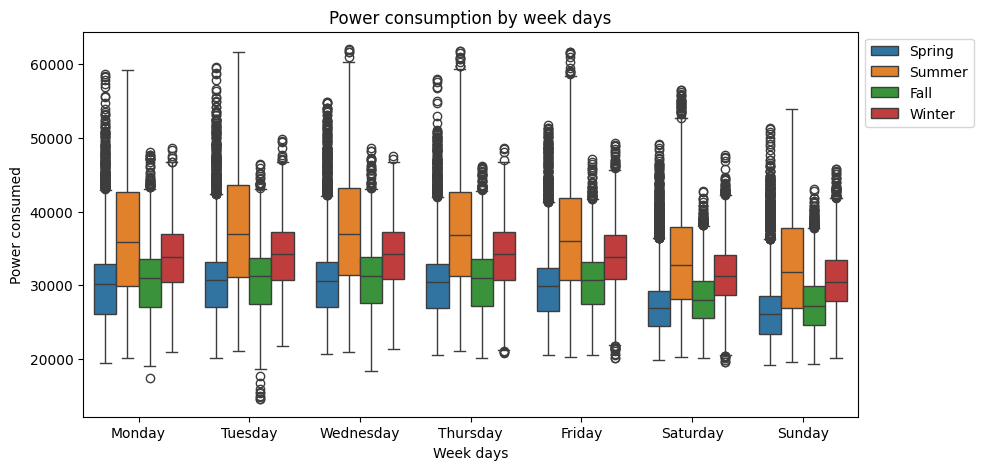

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=features_and_target, x = 'weekday', y = 'PJME_MW', hue ='season', linewidth=1, ax=ax)
ax.set_title('Power consumption by week days')
ax.set_xlabel('Week days')
ax.set_ylabel('Power consumed')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

<Axes: xlabel='Datetime'>

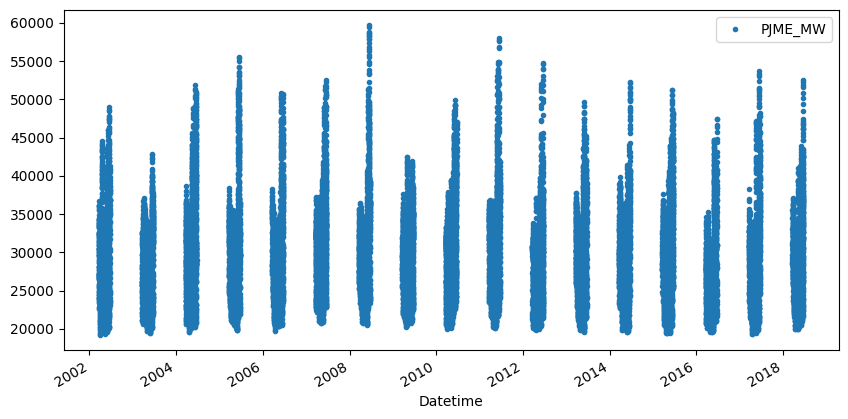

In [8]:
spring_energy_consumption = features_and_target[features_and_target['season'] == 'Spring']
spring_energy_consumption[spring_energy_consumption['PJME_MW'] <= spring_energy_consumption['PJME_MW'].max()][['PJME_MW']].plot(figsize=(10,5), kind='line', style='.')

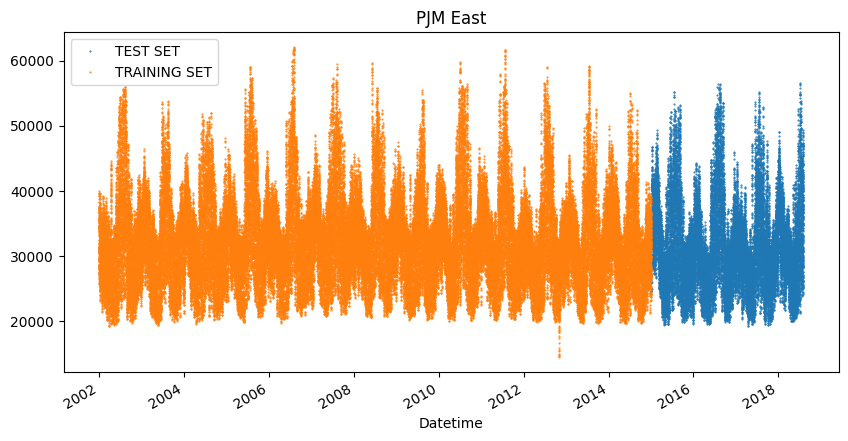

In [9]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

# Plot train and test so you can see where we have split
pjme_test \
    .rename(columns={'PJME_MW': 'TEST SET'}) \
    .join(pjme_train.rename(columns={'PJME_MW': 'TRAINING SET'}),how='outer') \
    .plot(figsize=(10, 5), title='PJM East', style='.', ms=1)
plt.show()

# Simple Prophet Model
* Prophet model expects the dataset to be named a specific way. We will rename our dataframe columns before feeding it into the model.
  - Datetime column named: ds
  - target : y

In [10]:
# Format data for prophet model using ds and y
pjme_train_prophet = pjme_train.reset_index() \
    .rename(columns={'Datetime':'ds','PJME_MW':'y'})
pjme_train_prophet

,ds,y
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
113922,2014-01-01 20:00:00,36193.0
113923,2014-01-01 21:00:00,35601.0
113924,2014-01-01 22:00:00,34242.0
113925,2014-01-01 23:00:00,32215.0


In [11]:
model = Prophet()
model.fit(pjme_train_prophet)

19:46:39 - cmdstanpy - INFO - Chain [1] start processing
19:49:17 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# Predict on test set with model
pjme_test_prophet = pjme_test.reset_index() \
    .rename(columns={'Datetime':'ds','PJME_MW':'y'})

pjme_test_fcst = model.predict(pjme_test_prophet)

In [13]:
pjme_test_fcst

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31201.981348,23724.050139,32920.922943,31201.981348,31201.981348,-2854.446190,-2854.446190,-2854.446190,-4430.339161,...,1281.369753,1281.369753,1281.369753,294.523218,294.523218,294.523218,0.0,0.0,0.0,28347.535158
1,2015-01-01 02:00:00,31201.943346,22190.394141,31403.774672,31201.943346,31201.943346,-4358.771252,-4358.771252,-4358.771252,-5927.206404,...,1272.617499,1272.617499,1272.617499,295.817653,295.817653,295.817653,0.0,0.0,0.0,26843.172095
2,2015-01-01 03:00:00,31201.905344,21222.675837,30418.901379,31201.905344,31201.905344,-5230.477050,-5230.477050,-5230.477050,-6790.290152,...,1262.659492,1262.659492,1262.659492,297.153610,297.153610,297.153610,0.0,0.0,0.0,25971.428294
3,2015-01-01 04:00:00,31201.867342,21227.785501,30660.939367,31201.867342,31201.867342,-5372.095148,-5372.095148,-5372.095148,-6922.245515,...,1251.619252,1251.619252,1251.619252,298.531115,298.531115,298.531115,0.0,0.0,0.0,25829.772194
4,2015-01-01 05:00:00,31201.829340,22075.719161,30786.343499,31201.829340,31201.829340,-4697.831866,-4697.831866,-4697.831866,-6237.414569,...,1239.632510,1239.632510,1239.632510,299.950193,299.950193,299.950193,0.0,0.0,0.0,26503.997473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31434,2018-08-02 20:00:00,30007.384613,-1352.426186,85487.486443,-12839.745866,73305.866932,11285.938749,11285.938749,11285.938749,4451.172851,...,1033.894875,1033.894875,1033.894875,5800.871022,5800.871022,5800.871022,0.0,0.0,0.0,41293.323362
31435,2018-08-02 21:00:00,30007.346611,-2265.378753,83960.277064,-12841.129415,73309.053873,10513.136330,10513.136330,10513.136330,3695.939003,...,1021.272963,1021.272963,1021.272963,5795.924363,5795.924363,5795.924363,0.0,0.0,0.0,40520.482941
31436,2018-08-02 22:00:00,30007.308609,-3196.062738,81059.791895,-12842.512964,73312.240815,8883.872711,8883.872711,8883.872711,2084.404638,...,1008.491929,1008.491929,1008.491929,5790.976144,5790.976144,5790.976144,0.0,0.0,0.0,38891.181320
31437,2018-08-02 23:00:00,30007.270607,-4482.618570,80999.564404,-12843.896513,73315.427757,6676.091396,6676.091396,6676.091396,-105.292780,...,995.357724,995.357724,995.357724,5786.026453,5786.026453,5786.026453,0.0,0.0,0.0,36683.362003


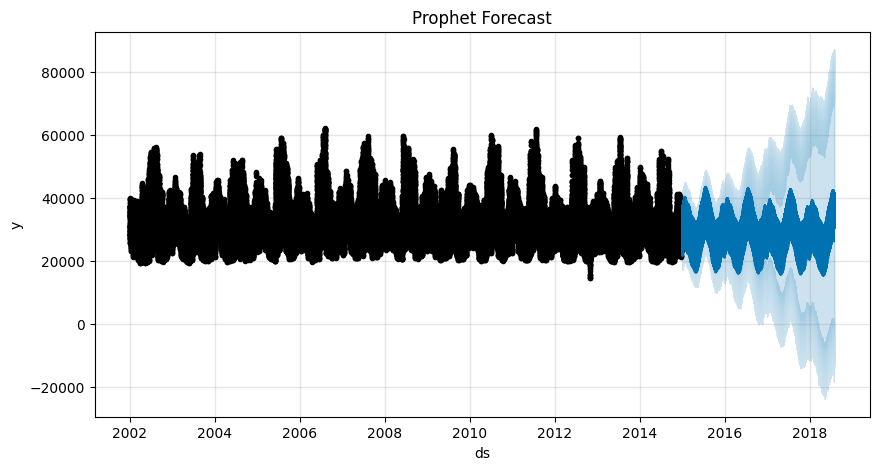

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

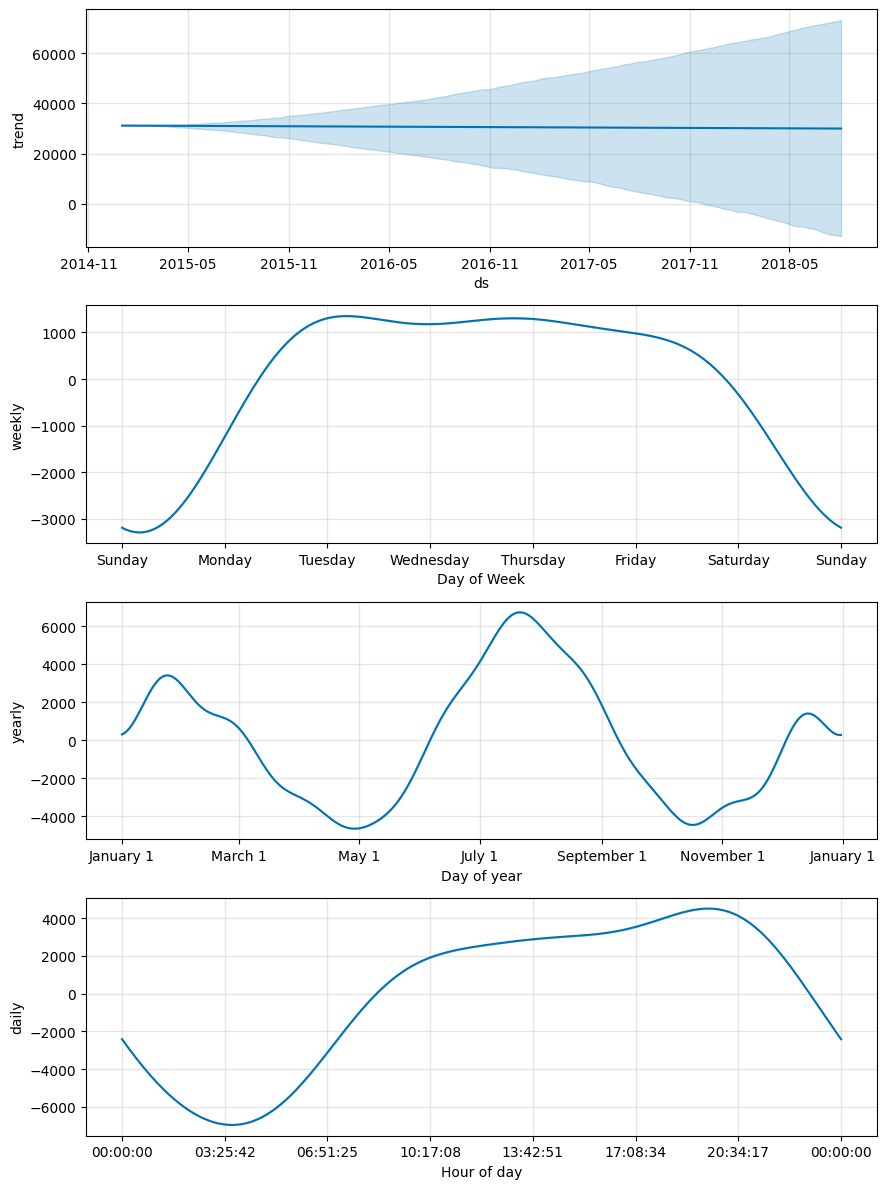

In [15]:
fig = model.plot_components(pjme_test_fcst)
plt.show()

## Compare forecast to actual values

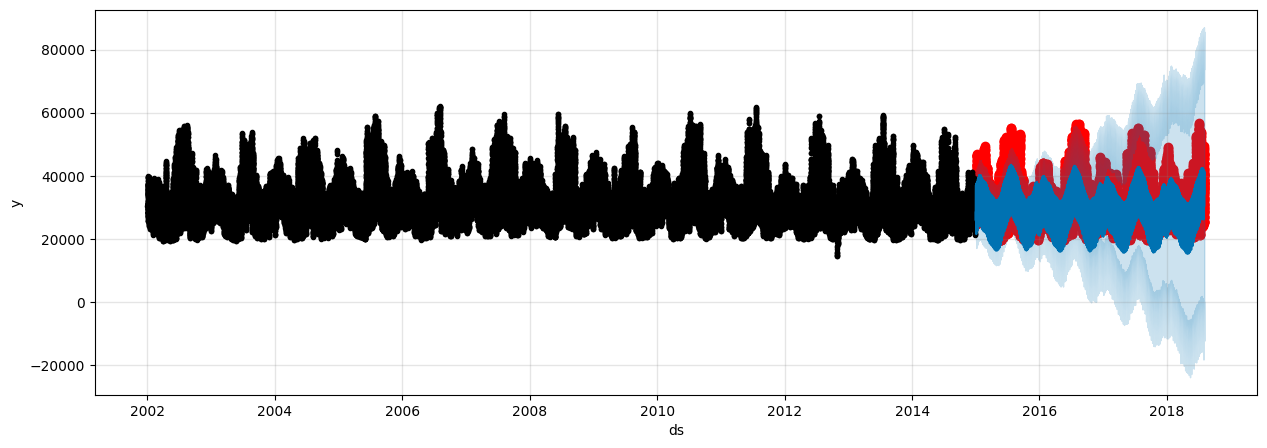

In [16]:
# Plot the forecast with the actual values
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)

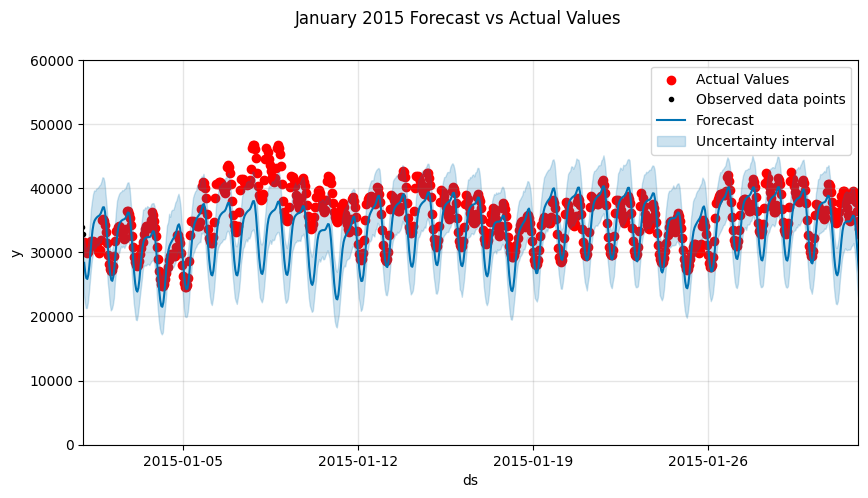

In [17]:
lower_bound = pd.to_datetime('2015-01-01')
upper_bound = pd.to_datetime('2015-02-01')

# Plot forecast vs actual values
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r', label='Actual Values')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=lower_bound, upper=upper_bound)
ax.set_ylim(0, 60000)
plt.suptitle('January 2015 Forecast vs Actual Values')
plt.legend()
plt.show()

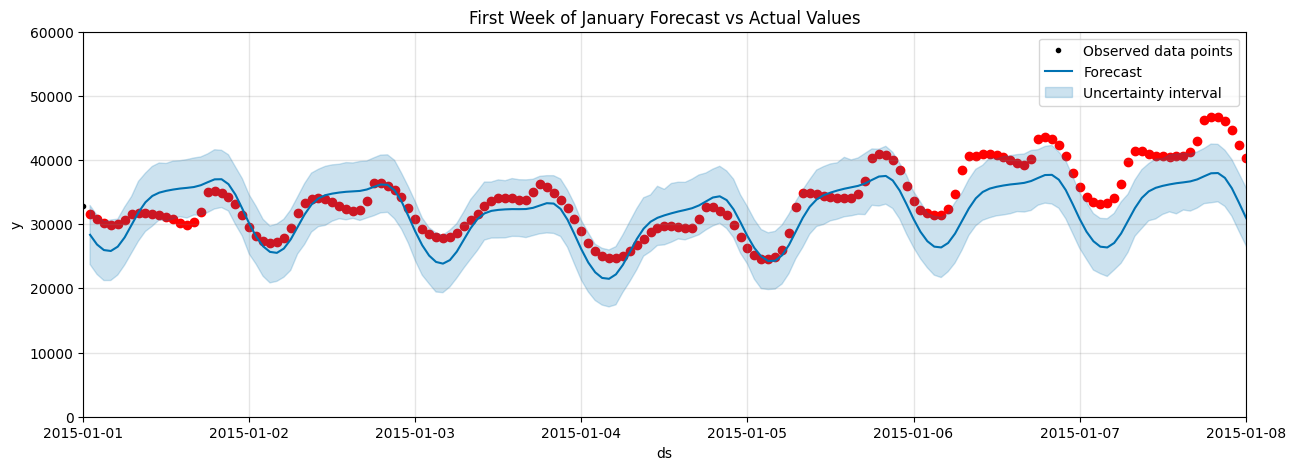

In [18]:
# Plot the forecast with the actual values
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=pd.to_datetime('01-01-2015'), upper=pd.to_datetime('01-08-2015'))
ax.set_ylim(0, 60000)
ax.set_title('First Week of January Forecast vs Actual Values')
plt.legend()
plt.show()

## Model error calculation metrics

In [19]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat']))

6619.1694821356

In [20]:
mean_absolute_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat'])

5183.4263283888395

In [21]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat'])

0.16508491433751185

## Adding Holidays
Next we will see if adding holiday indicators will help the accuracy of the model. Prophet comes with a Holiday Effects parameter that can be provided to the model prior to training.

We will use the built in pandas USFederalHolidayCalendar to pull the list of holidays

In [22]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

cal = calendar()
holidays = cal.holidays(start=pjme.index.min(),end=pjme.index.max(),return_name=True)
holiday_df = pd.DataFrame(data=holidays,columns=['holiday'])
holiday_df = holiday_df.reset_index().rename(columns={'index':'ds'})

holiday_df

,ds,holiday
0,2002-01-21,"Birthday of Martin Luther King, Jr."
1,2002-02-18,Washington's Birthday
2,2002-05-27,Memorial Day
3,2002-07-04,Independence Day
4,2002-09-02,Labor Day
...,...,...
159,2018-01-01,New Year's Day
160,2018-01-15,"Birthday of Martin Luther King, Jr."
161,2018-02-19,Washington's Birthday
162,2018-05-28,Memorial Day


In [23]:
model_with_holidays = Prophet(holidays=holiday_df)
model_with_holidays.fit(pjme_train_prophet)

19:50:23 - cmdstanpy - INFO - Chain [1] start processing
19:53:30 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
# Predict on training set with model
pjme_test_fcst_with_hols = \
    model_with_holidays.predict(df=pjme_test_prophet)

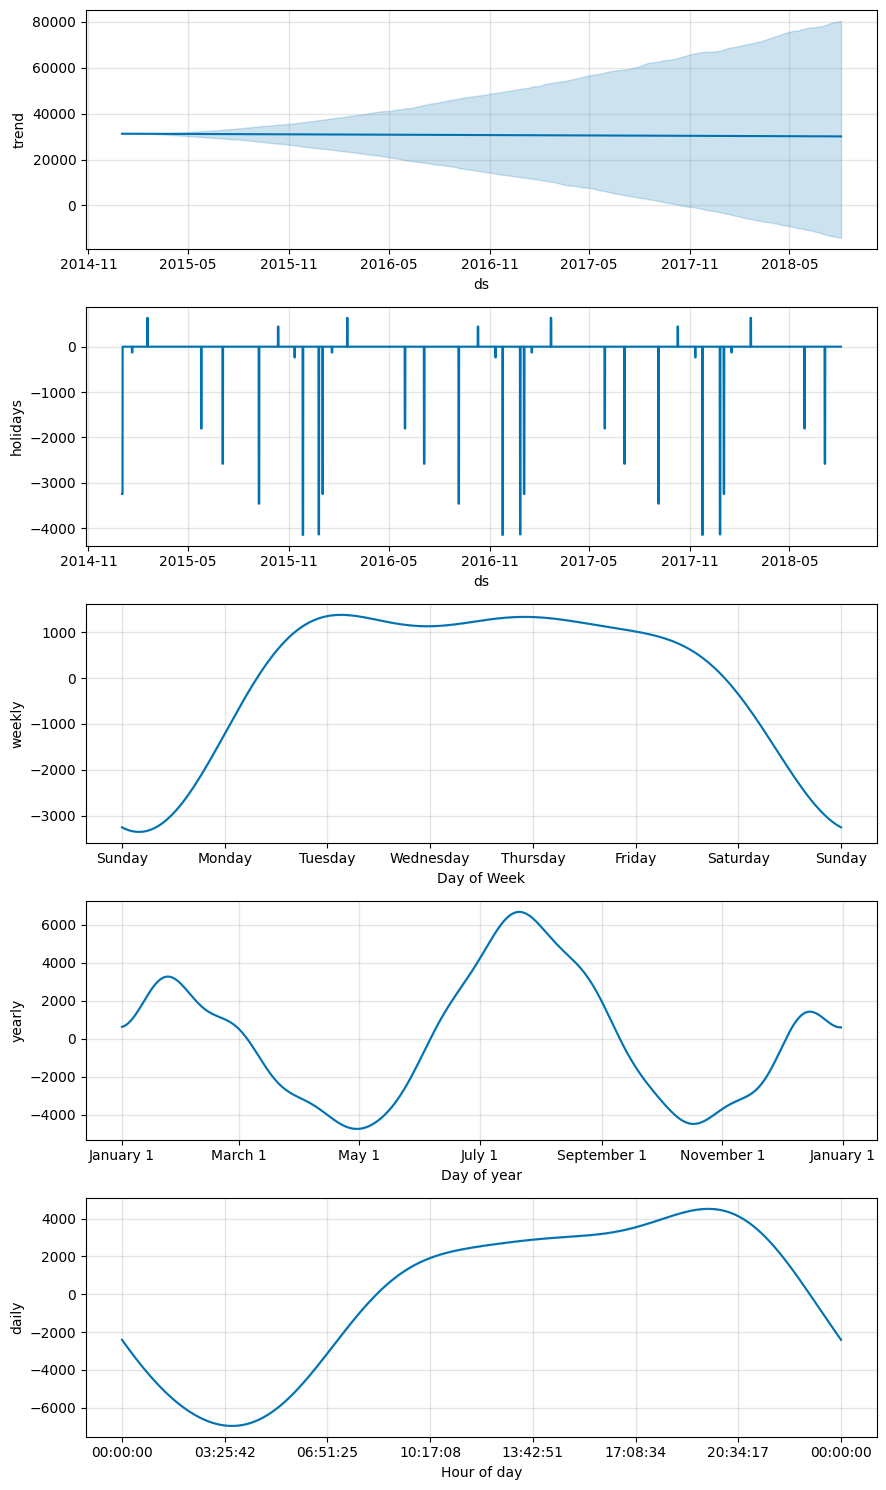

In [25]:
fig = model_with_holidays.plot_components(
    pjme_test_fcst_with_hols)
plt.show()

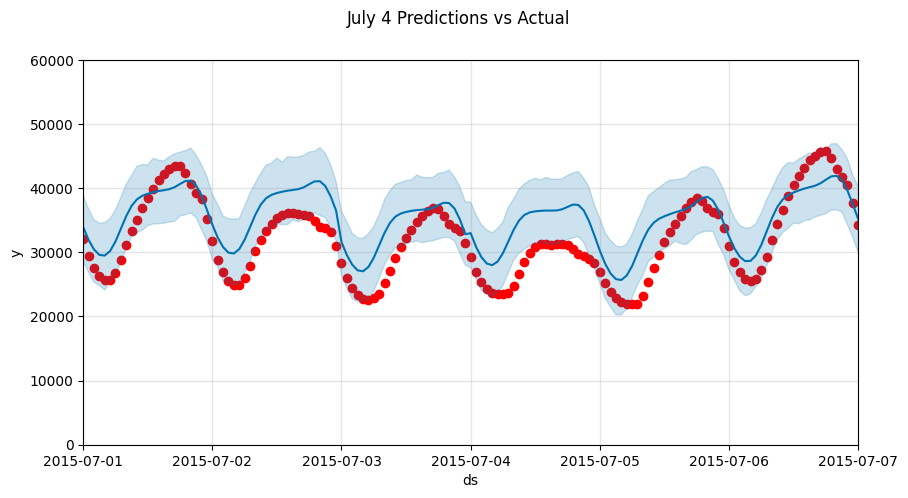

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst_with_hols, ax=ax)
ax.set_xbound(lower=pd.to_datetime('07-01-2015'), upper=pd.to_datetime('07-07-2015'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('July 4 Predictions vs Actual')

### Error metrics of holiday oriented model

In [27]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat']))

6636.386219299027

In [28]:
mean_absolute_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat'])

5199.177464481246

In [29]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat'])

0.1656706339008402

## Predict into the Future
We can use the built in `make_future_dataframe` method to build our future dataframe and make predictions.

In [30]:
future = model.make_future_dataframe(periods=365*24, freq='h', include_history=False)
forecast = model_with_holidays.predict(future)

forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,"Birthday of Martin Luther King, Jr.","Birthday of Martin Luther King, Jr._lower","Birthday of Martin Luther King, Jr._upper",Christmas Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31260.656768,21091.760310,30057.669651,31260.656768,31260.656768,0.0,0.0,0.0,0.0,...,1324.569510,1324.569510,1324.569510,623.481309,623.481309,623.481309,0.0,0.0,0.0,25530.561243
1,2015-01-01 02:00:00,31260.619605,19403.812633,28810.799931,31260.619605,31260.619605,0.0,0.0,0.0,0.0,...,1318.794952,1318.794952,1318.794952,624.406235,624.406235,624.406235,0.0,0.0,0.0,24028.616526
2,2015-01-01 03:00:00,31260.582441,18535.684720,27556.630003,31260.582441,31260.582441,0.0,0.0,0.0,0.0,...,1311.478366,1311.478366,1311.478366,625.364977,625.364977,625.364977,0.0,0.0,0.0,23159.048584
3,2015-01-01 04:00:00,31260.545277,18594.196896,27288.215934,31260.545277,31260.545277,0.0,0.0,0.0,0.0,...,1302.730545,1302.730545,1302.730545,626.357573,626.357573,626.357573,0.0,0.0,0.0,23019.367400
4,2015-01-01 05:00:00,31260.508113,19205.580101,28118.773055,31260.508113,31260.508113,0.0,0.0,0.0,0.0,...,1292.678166,1292.678166,1292.678166,627.384060,627.384060,627.384060,0.0,0.0,0.0,23695.279750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2015-12-31 20:00:00,30935.288431,30249.322925,44537.440731,25433.899637,37069.636233,0.0,0.0,0.0,0.0,...,1076.789255,1076.789255,1076.789255,615.526657,615.526657,615.526657,0.0,0.0,0.0,37078.630579
8756,2015-12-31 21:00:00,30935.251268,29889.268072,43728.251043,25432.423828,37070.703727,0.0,0.0,0.0,0.0,...,1061.628335,1061.628335,1061.628335,616.082527,616.082527,616.082527,0.0,0.0,0.0,36308.819388
8757,2015-12-31 22:00:00,30935.214104,28121.319013,42695.476503,25430.948019,37071.771221,0.0,0.0,0.0,0.0,...,1046.203208,1046.203208,1046.203208,616.671701,616.671701,616.671701,0.0,0.0,0.0,34682.580963
8758,2015-12-31 23:00:00,30935.176940,25568.429241,39940.944744,25429.472210,37072.838715,0.0,0.0,0.0,0.0,...,1030.342961,1030.342961,1030.342961,617.294233,617.294233,617.294233,0.0,0.0,0.0,32477.761828


# Making forecast using my own creativity

# Timeseries EDA

## Finding lags and their correlations

<Figure size 1200x1000 with 0 Axes>

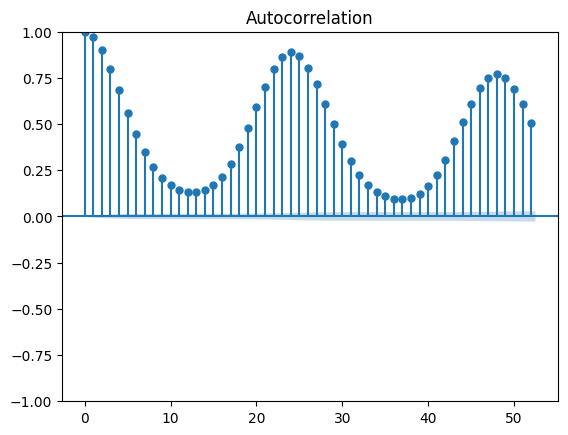

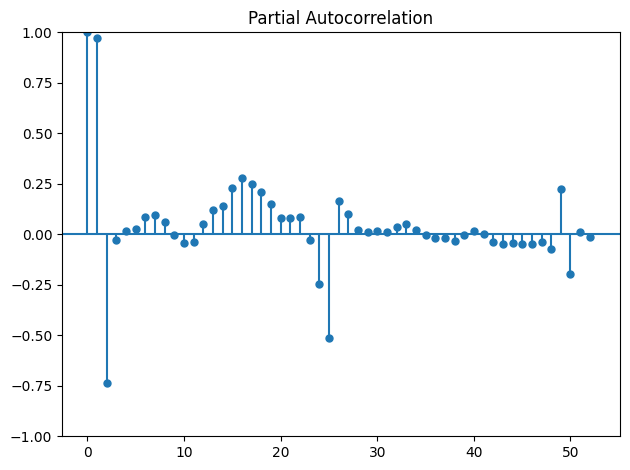

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,10))

plot_acf(pjme['PJME_MW'])
plot_pacf(pjme['PJME_MW'])

plt.tight_layout()
plt.show()

## Stationarity check

In [32]:
from statsmodels.tsa.stattools import adfuller
from numpy.typing import ArrayLike

def adf_stationarity_test(series: ArrayLike):
    adf_test_val = adfuller(series)

    print("ADF statistic: ", adf_test_val[0])
    print("P-value: ", adf_test_val[1])
    print("Critical values: ")
    for key, val in adf_test_val[4].items():
        print(f"  {key}: {val}")

In [33]:
adf_stationarity_test(pjme['PJME_MW'])

ADF statistic:  -18.828912729084156
P-value:  2.022124508152674e-30
Critical values: 
  1%: -3.430395009088914
  5%: -2.861559893380481
  10%: -2.5667805885384065


*Conclusion*: The p-value 2.022124508152674e-30 using adf test, which is low than 0.05, thus; rejecting the null hypothesis that the series at hand is non-stationary.

## White noise

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from numpy.typing import ArrayLike

def white_noise_test(series: ArrayLike, lags=[50]):
    return acorr_ljungbox(series, lags=lags)

In [35]:
white_noise_test(pjme['PJME_MW'])

,lb_stat,lb_pvalue
50,2.010248e+06,0.0


*Conclusion*: The p-value of 0.0, less than 0.05 indicates that series at hand is not a white noise.

## Random walk

In [36]:
from arch.unitroot import VarianceRatio
from numpy.typing import ArrayLike

def random_walk_test(series: ArrayLike, lags=50):
    var_ratio = VarianceRatio(series, lags)
    return var_ratio.stat, var_ratio.pvalue

In [37]:
random_walk_test(pjme['PJME_MW'])

(-34.71092217200509, 0.0)

*Conclusion*: The p-value of 0.0 indicates that the null hypothesis of series at hand being a random walk is rejected.

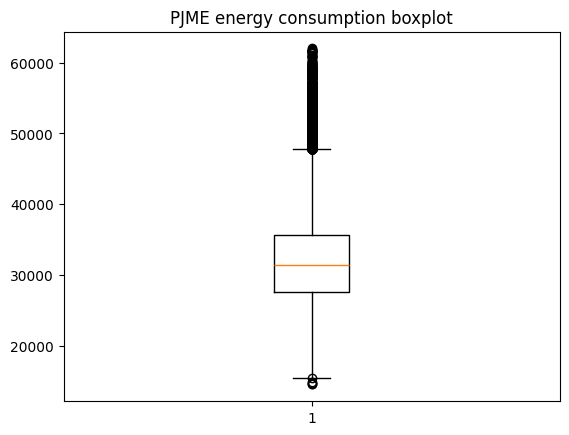

In [38]:
plt.title("PJME energy consumption boxplot")
plt.boxplot(pjme['PJME_MW'])
plt.show()

## Data distribution

### Seasonality decomposition

<Figure size 1500x500 with 0 Axes>

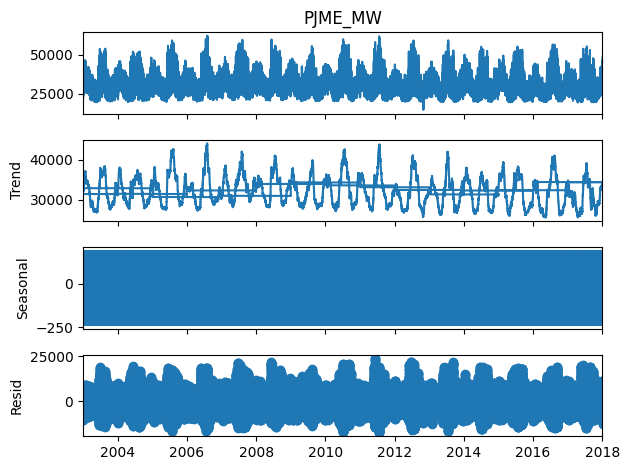

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonally_decomposed = seasonal_decompose(x=pjme['PJME_MW'], period=365)

plt.figure(figsize=(15,5))
seasonally_decomposed.plot()
plt.show()

In [40]:
from statsmodels.tsa.seasonal import STL

def stl_decomposition(series: ArrayLike, period=12):
    stl = STL(endog=series, period=period)
    result = stl.fit()

    # Plot the components
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    ax1.plot(pjme['PJME_MW'], label='Original Data')
    ax1.legend(loc='upper left')
    ax2.plot(result.trend, label='Trend', color='orange')
    ax2.legend(loc='upper left')
    ax3.plot(result.seasonal, label='Seasonal', color='green')
    ax3.legend(loc='upper left')
    ax4.plot(result.resid, label='Residual', color='red')
    ax4.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    return result.trend, result.seasonal, result.resid

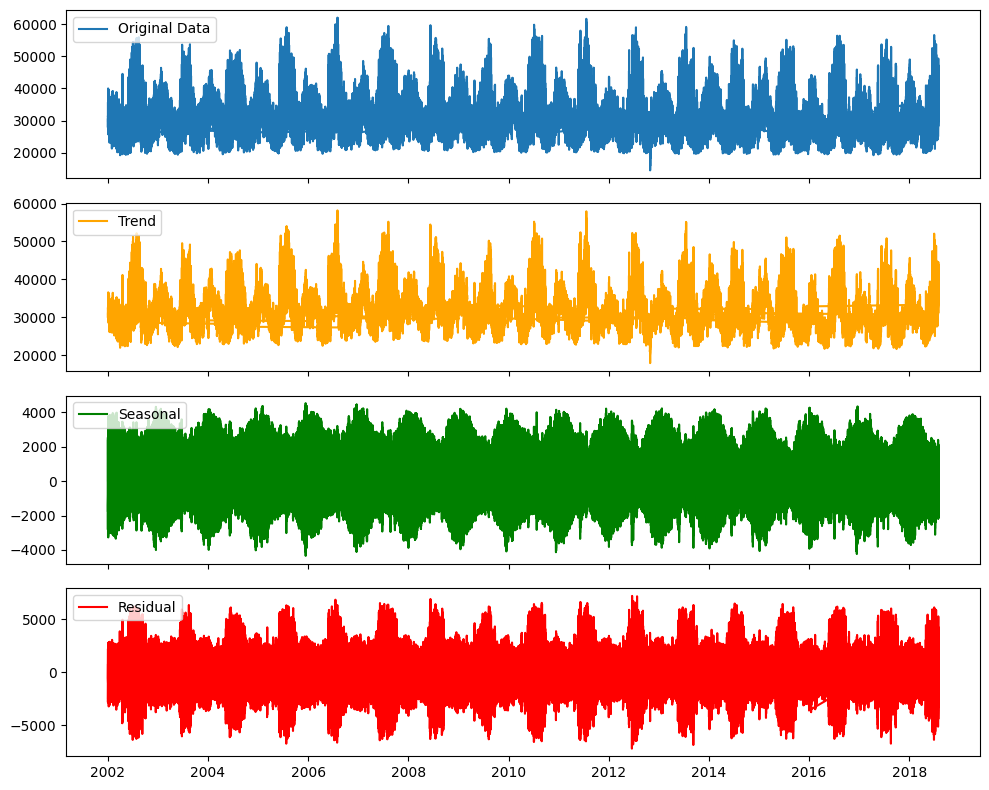

(Datetime
 2002-12-31 01:00:00    28812.937536
 2002-12-31 02:00:00    28874.987925
 2002-12-31 03:00:00    28940.985632
 2002-12-31 04:00:00    29011.216211
 2002-12-31 05:00:00    29086.686019
                            ...     
 2018-01-01 20:00:00    40726.704204
 2018-01-01 21:00:00    40759.679107
 2018-01-01 22:00:00    40789.085878
 2018-01-01 23:00:00    40814.966992
 2018-01-02 00:00:00    40837.429591
 Name: trend, Length: 145366, dtype: float64,
 Datetime
 2002-12-31 01:00:00    -965.667881
 2002-12-31 02:00:00   -1953.887306
 2002-12-31 03:00:00   -2528.239891
 2002-12-31 04:00:00   -2727.042685
 2002-12-31 05:00:00   -1882.132668
                           ...     
 2018-01-01 20:00:00    2880.015801
 2018-01-01 21:00:00    2463.346419
 2018-01-01 22:00:00    1335.144030
 2018-01-01 23:00:00    -209.264909
 2018-01-02 00:00:00   -1538.698156
 Name: season, Length: 145366, dtype: float64,
 Datetime
 2002-12-31 01:00:00   -1349.269655
 2002-12-31 02:00:00   -1774.100619
 2

In [41]:
stl_decomposition(pjme['PJME_MW'])

<Axes: xlabel='PJME_MW', ylabel='Count'>

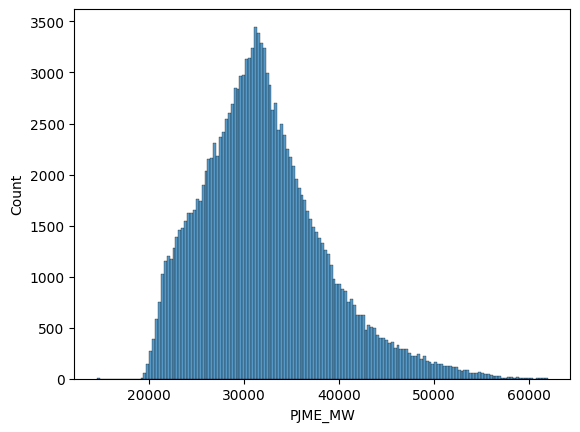

In [42]:
sns.histplot(pjme['PJME_MW'])

## Handling outlier

In [43]:
mw_q1 = pjme['PJME_MW'].quantile(0.25)
mw_q3 = pjme['PJME_MW'].quantile(0.75)

mw_IQR = mw_q3 - mw_q1

mw_ub = mw_q3 + 1.5 * mw_IQR
mw_lb = mw_q1 - 1.5 * mw_IQR

outlier_ts = pjme[(pjme['PJME_MW'] < mw_lb) | (pjme['PJME_MW'] > mw_ub)]
outlier_ts

,PJME_MW
Datetime,
2002-08-22 16:00:00,48285.0
2002-08-22 17:00:00,48587.0
2002-08-22 18:00:00,48302.0
2002-08-20 14:00:00,48052.0
2002-08-20 15:00:00,48656.0
...,...
2018-06-18 21:00:00,48437.0
2018-01-05 18:00:00,48945.0
2018-01-05 19:00:00,49021.0


<Axes: ylabel='PJME_MW'>

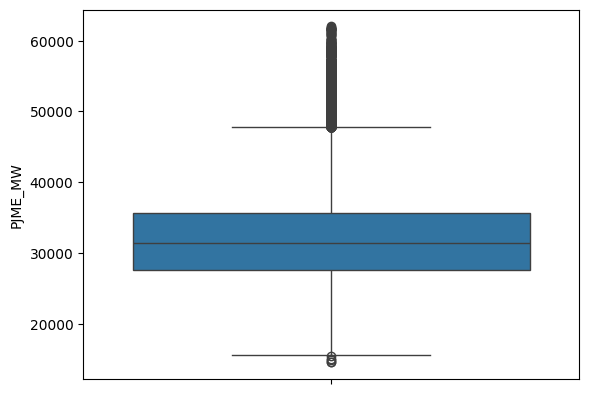

In [44]:
sns.boxplot(data=pjme['PJME_MW'])

<Axes: xlabel='Datetime'>

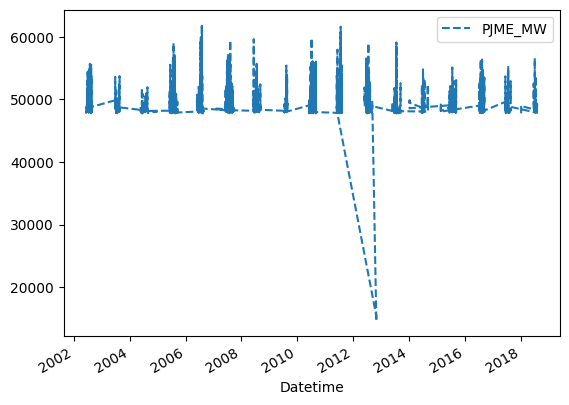

In [45]:
outlier_ts.plot(style='--')

<Axes: xlabel='PJME_MW', ylabel='Count'>

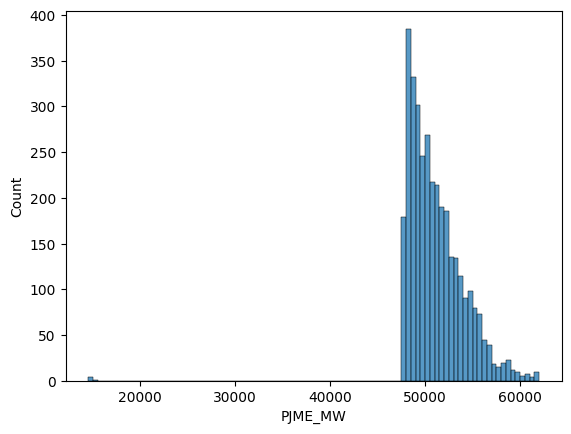

In [46]:
sns.histplot(outlier_ts['PJME_MW'])

In [47]:
outlier_ts.describe()

,PJME_MW
count,3455.000000
mean,51133.205499
std,3070.815615
min,14544.000000
25%,48974.000000
50%,50535.000000
75%,52758.000000
max,62009.000000


In [48]:
pjme.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


Original Data: Mean = 32080.222830648156 , Std = 6463.989932797986
Winsorized Data: Mean = 31981.18417649244 , Std = 6160.067345445618


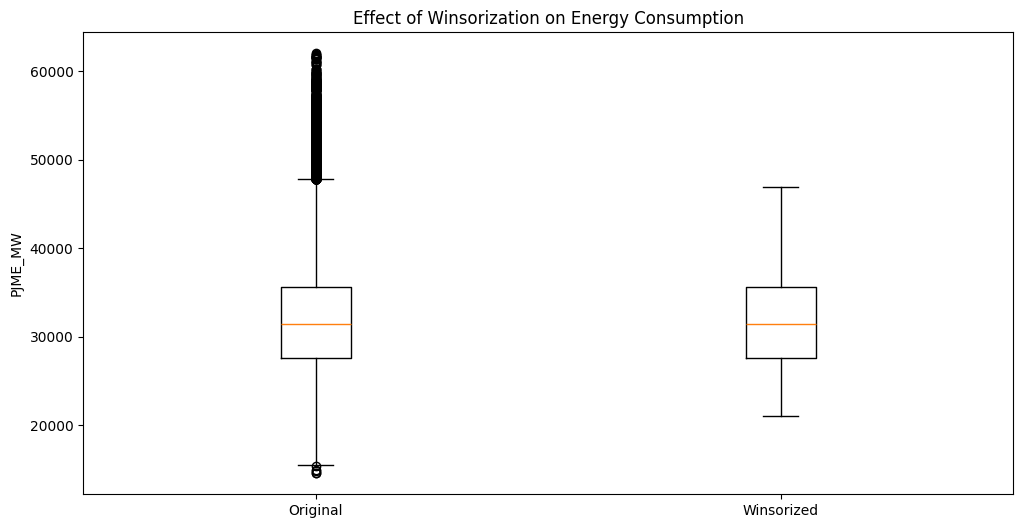

In [49]:
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

# Sort the data by datetime index to ensure consistency (if not already sorted)
# pjme.sort_index(inplace=True)

# Making another copy of the current dataframe so that original remains as it is.
pjme_copy = pjme.copy()

data = pjme['PJME_MW'].values

winsorized_data = winsorize(data, limits=[0.01, 0.029])  # 1% lower, 2.9% upper capping

pjme_copy['PJME_MW_Winsorized'] = winsorized_data

print("Original Data: Mean =", data.mean(), ", Std =", data.std())
print("Winsorized Data: Mean =", winsorized_data.mean(), ", Std =", winsorized_data.std())

plt.figure(figsize=(12, 6))
plt.boxplot([data, winsorized_data], labels=['Original', 'Winsorized'])
plt.title('Effect of Winsorization on Energy Consumption')
plt.ylabel('PJME_MW')
plt.show()

<Axes: xlabel='PJME_MW_Winsorized', ylabel='Count'>

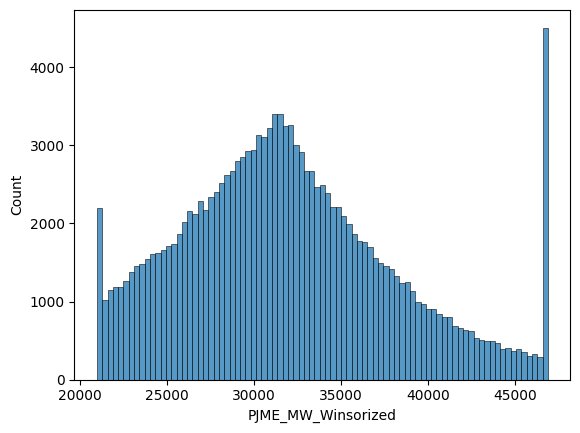

In [52]:
sns.histplot(data=pjme_copy, x='PJME_MW_Winsorized')

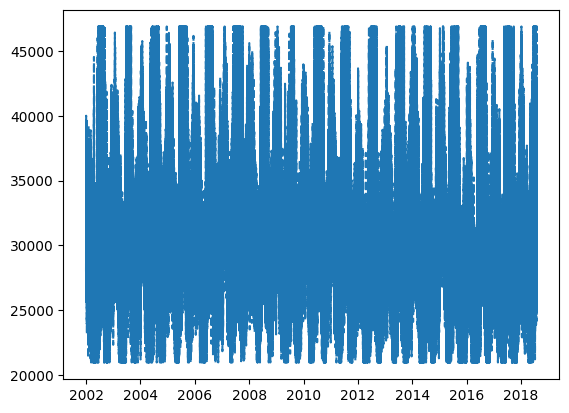

In [50]:
plt.plot(pjme_copy['PJME_MW_Winsorized'], linestyle='--')

In [53]:
pjme_copy.describe()

,PJME_MW,PJME_MW_Winsorized
count,145366.000000,145366.000000
mean,32080.222831,31981.184176
std,6464.012166,6160.088534
min,14544.000000,20968.000000
25%,27573.000000,27573.000000
50%,31421.000000,31421.000000
75%,35650.000000,35650.000000
max,62009.000000,46887.000000


<Figure size 1200x1000 with 0 Axes>

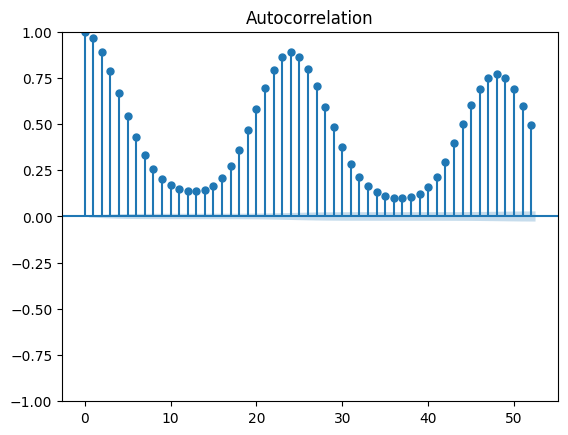

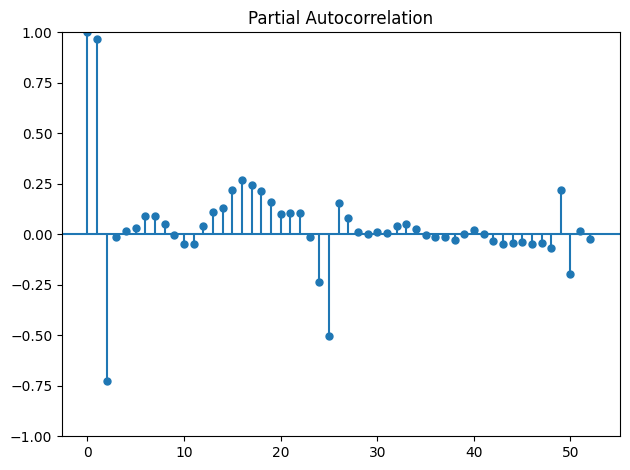

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,10))

plot_acf(pjme_copy['PJME_MW_Winsorized'])
plot_pacf(pjme_copy['PJME_MW_Winsorized'])

plt.tight_layout()
plt.show()

In [57]:
mw_q1 = pjme_copy['PJME_MW_Winsorized'].quantile(0.25)
mw_q3 = pjme_copy['PJME_MW_Winsorized'].quantile(0.75)

mw_IQR = mw_q3 - mw_q1

mw_ub = mw_q3 + 1.5 * mw_IQR
mw_lb = mw_q1 - 1.5 * mw_IQR

outlier_ts_ws = pjme_copy[(pjme_copy['PJME_MW_Winsorized'] < mw_lb) | (pjme_copy['PJME_MW_Winsorized'] > mw_ub)]
outlier_ts_ws

,PJME_MW,PJME_MW_Winsorized
Datetime,,


In [55]:
adf_stationarity_test(pjme_copy['PJME_MW_Winsorized'])

ADF statistic:  -18.87170311536198
P-value:  0.0
Critical values: 
  1%: -3.4303950093987075
  5%: -2.8615598935174043
  10%: -2.566780588611286


The results of the stationarity test indicate the following:

##### **Interpretation of the ADF Test Results**
1. **ADF Statistic**: 
   - The ADF statistic is **-18.87**. This value is a very large negative number, which strongly suggests stationarity.

2. **P-value**:
   - The **p-value is 0.0**, meaning it's less than any common significance level (e.g., 0.01, 0.05, 0.1). This means you can reject the null hypothesis of the test.

3. **Critical Values**:
   - At all significance levels (1%, 5%, and 10%), the ADF statistic is lower than the critical values:
     - **1%**: -18.87 < -3.43
     - **5%**: -18.87 < -2.86
     - **10%**: -18.87 < -2.57

##### **Conclusion**
- The test **rejects the null hypothesis** (which assumes that the series has a unit root and is non-stationary).
- Your `PJME_MW_Winsorized` series appears to be **stationary**, meaning its statistical properties (e.g., mean, variance, autocorrelation) do not change over time.

In [56]:
white_noise_test(pjme_copy['PJME_MW_Winsorized'])

,lb_stat,lb_pvalue
50,1.964272e+06,0.0


##### Interpretation of the Ljung-Box Test Results:
The Ljung-Box test checks for the presence of autocorrelation in a time series. Here’s what results suggest:

##### **Results:**
1. **`lb_stat` (Ljung-Box statistic):**
   - The value **1,964,272** is very large, indicating a significant amount of serial correlation in the data.

2. **`lb_pvalue` (p-value for the test):**
   - The p-value is **0.0**, which is below any standard significance level (e.g., 0.05, 0.01, 0.1). This means you can **reject the null hypothesis** of the test.

##### **Null Hypothesis (H₀):**
The null hypothesis assumes that the time series is **white noise** (i.e., no autocorrelation at any lag).

##### **Conclusion:**
- Since the p-value is effectively 0, you reject the null hypothesis. This means the series **is not white noise** and exhibits **significant autocorrelation**.

In [59]:
random_walk_test(pjme_copy['PJME_MW_Winsorized'])

(-36.02156634562515, 0.0)

##### Interpretation of the Variance Ratio Test Results:

The Variance Ratio Test is used to check whether a time series follows a **random walk**, which implies that successive values in the series are independent and identically distributed.

---

##### **Results:**

1. **`stat` (Variance Ratio Statistic):**
   - The statistic is **-36.0216**, which is a very large negative value. This indicates that the series strongly deviates from the behavior of a random walk.

2. **`pvalue` (p-value):**
   - The p-value is **0.0**, which is less than any standard significance level (e.g., 0.05, 0.01). This allows you to **reject the null hypothesis** of the test.

---

##### **Null Hypothesis (H₀):**
The null hypothesis assumes that the series follows a **random walk**.

---

##### **Conclusion:**
- Since the p-value is effectively 0, you **reject the null hypothesis**, indicating that the series **does not follow a random walk**. This implies:
  - The series likely has some form of deterministic pattern, trend, or mean-reverting behavior.
  - It is predictable to some degree and does not evolve purely randomly.

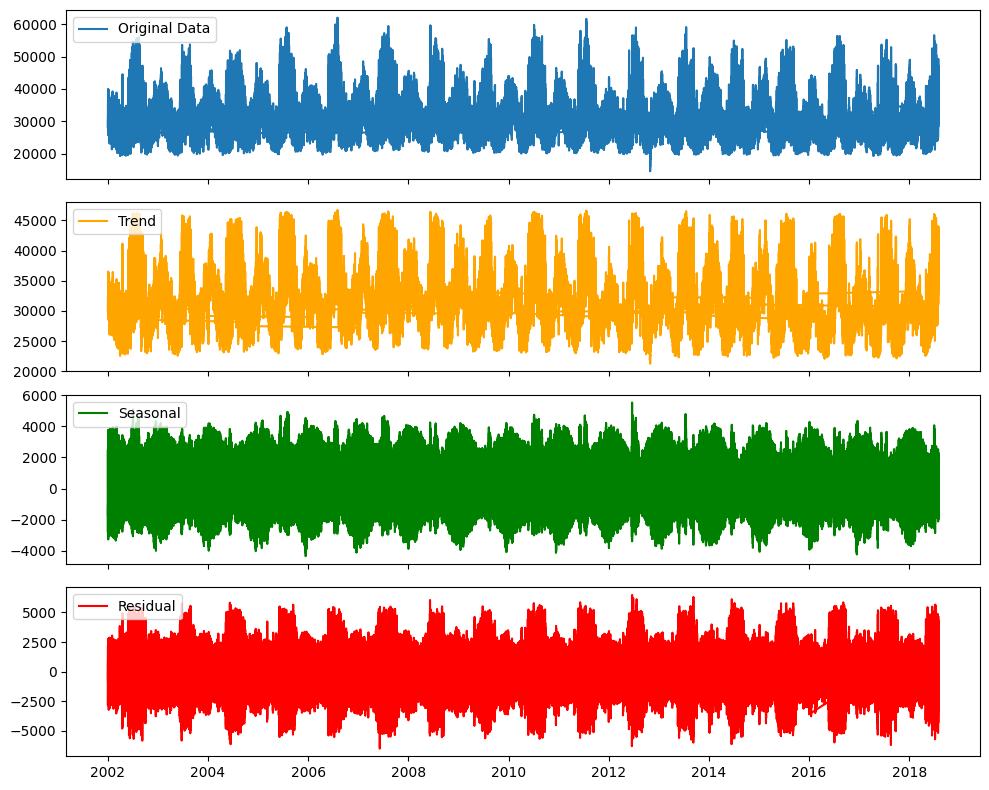

(Datetime
 2002-12-31 01:00:00    28812.937536
 2002-12-31 02:00:00    28874.987925
 2002-12-31 03:00:00    28940.985632
 2002-12-31 04:00:00    29011.216211
 2002-12-31 05:00:00    29086.686019
                            ...     
 2018-01-01 20:00:00    40726.692878
 2018-01-01 21:00:00    40759.667354
 2018-01-01 22:00:00    40789.073614
 2018-01-01 23:00:00    40814.954162
 2018-01-02 00:00:00    40837.416169
 Name: trend, Length: 145366, dtype: float64,
 Datetime
 2002-12-31 01:00:00    -965.667881
 2002-12-31 02:00:00   -1953.887306
 2002-12-31 03:00:00   -2528.239891
 2002-12-31 04:00:00   -2727.042685
 2002-12-31 05:00:00   -1882.132668
                           ...     
 2018-01-01 20:00:00    2880.080856
 2018-01-01 21:00:00    2463.400942
 2018-01-01 22:00:00    1335.186442
 2018-01-01 23:00:00    -209.236954
 2018-01-02 00:00:00   -1538.685802
 Name: season, Length: 145366, dtype: float64,
 Datetime
 2002-12-31 01:00:00   -1349.269655
 2002-12-31 02:00:00   -1774.100619
 2

In [58]:
mw_ws_trend, mw_ws_seasonal, mw_ws_resid = stl_decomposition(pjme_copy['PJME_MW_Winsorized'])
mw_ws_trend, mw_ws_seasonal, mw_ws_resid

## Feature Engineering for `pjme_copy`

I am gonna use the previously created function of `create_features` on my `pjme_copy` dataframe of timeseries.

In [60]:
from pandas.api.types import CategoricalDtype

category_types = CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

def create_features(
    df: pd.DataFrame,
    label=None
) -> tuple[pd.DataFrame, pd.DataFrame] | pd.DataFrame:
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(category_types)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])
    X = df[['hour','dayofweek','quarter','month','year','dayofyear','dayofmonth','weekofyear','weekday','season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(pjme_copy, label='PJME_MW_Winsorized')
pjme_winsorized_ts: pd.DataFrame = pd.concat([X, y], axis=1)

pjme_winsorized_ts

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW_Winsorized
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


## Power consumption in days as per season

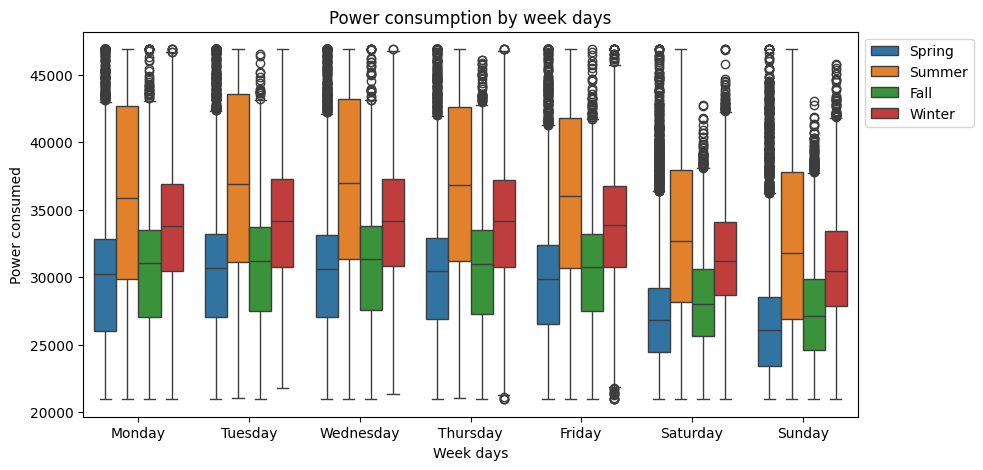

In [61]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=pjme_winsorized_ts, x = 'weekday', y = 'PJME_MW_Winsorized', hue ='season', linewidth=1, ax=ax)
ax.set_title('Power consumption by week days')
ax.set_xlabel('Week days')
ax.set_ylabel('Power consumed')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

## Power consumption by months and quarters

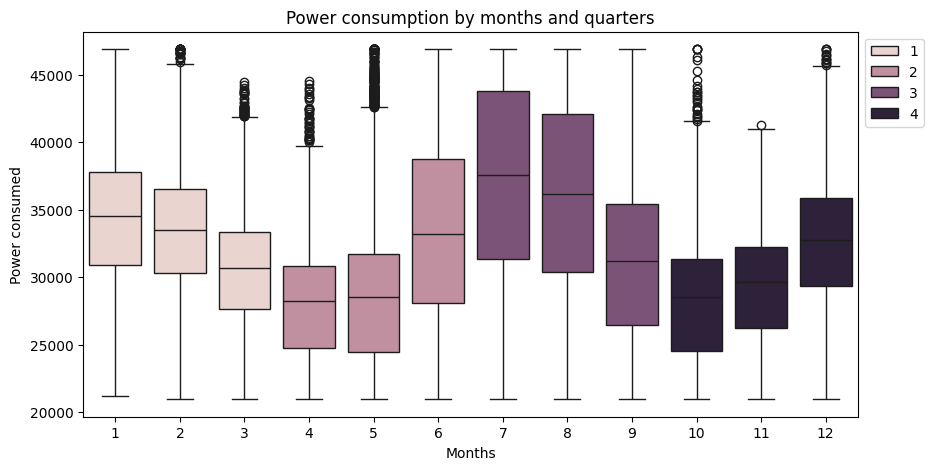

In [67]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=pjme_winsorized_ts, x = 'month', y = 'PJME_MW_Winsorized', hue ='quarter', linewidth=1, ax=ax)
ax.set_title('Power consumption by months and quarters')
ax.set_xlabel('Months')
ax.set_ylabel('Power consumed')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

## Power consumption by year and season

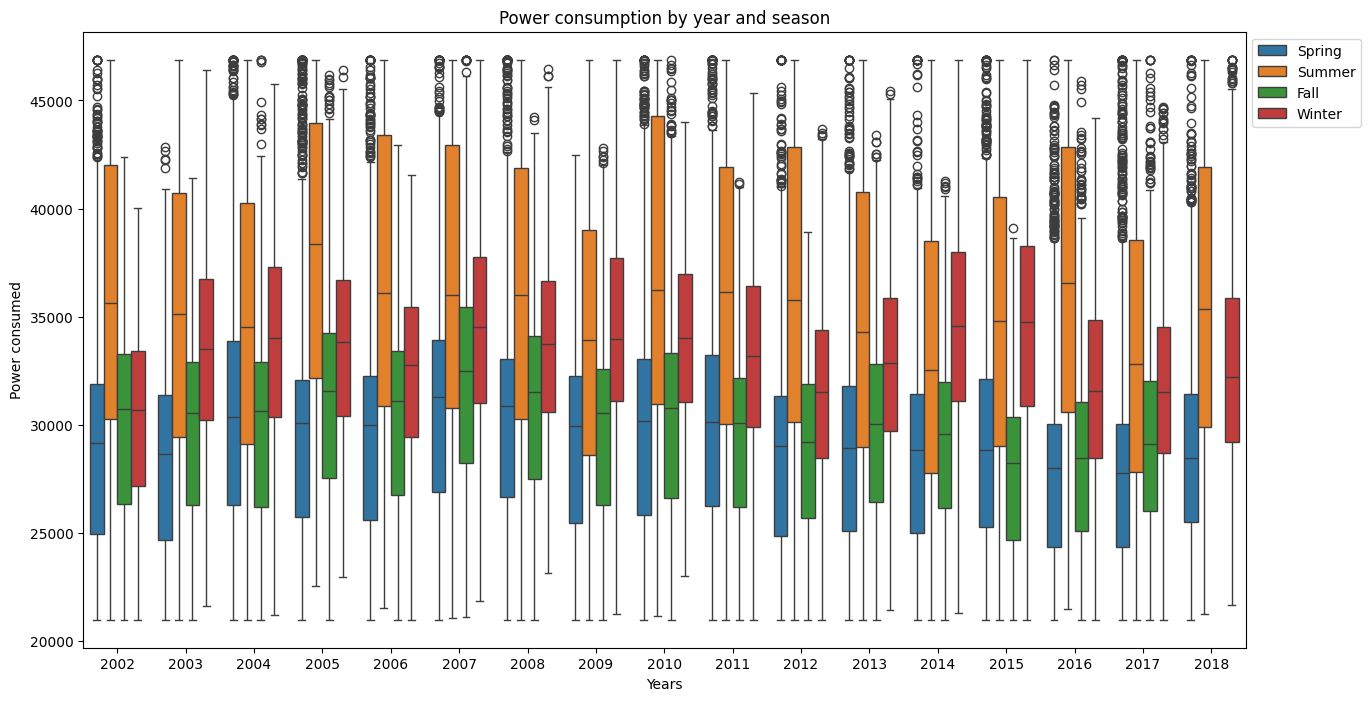

In [65]:
fig, ax = plt.subplots(figsize=(15,8))
sns.boxplot(data=pjme_winsorized_ts, x = 'year', y = 'PJME_MW_Winsorized', hue ='season', linewidth=1, ax=ax)
ax.set_title('Power consumption by year and season')
ax.set_xlabel('Years')
ax.set_ylabel('Power consumed')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

# Modeling

## Train test split

In [68]:
from pandas import to_datetime

split_date = to_datetime('2015-01-01')

train_mw_ts = pjme_winsorized_ts[pjme_winsorized_ts.index <= to_datetime('2016-01-01')]
test_mw_ts = pjme_winsorized_ts[pjme_winsorized_ts.index > split_date]

In [69]:
train_mw_ts

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW_Winsorized
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01 20:00:00,20,3,1,1,2015,1,1,1,Thursday,Winter,34832.0
2015-01-01 21:00:00,21,3,1,1,2015,1,1,1,Thursday,Winter,34302.0
2015-01-01 22:00:00,22,3,1,1,2015,1,1,1,Thursday,Winter,33227.0


In [70]:
test_mw_ts

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW_Winsorized
Datetime,,,,,,,,,,,
2015-12-31 01:00:00,1,3,4,12,2015,365,31,53,Thursday,Winter,24305.0
2015-12-31 02:00:00,2,3,4,12,2015,365,31,53,Thursday,Winter,23156.0
2015-12-31 03:00:00,3,3,4,12,2015,365,31,53,Thursday,Winter,22514.0
2015-12-31 04:00:00,4,3,4,12,2015,365,31,53,Thursday,Winter,22330.0
2015-12-31 05:00:00,5,3,4,12,2015,365,31,53,Thursday,Winter,22773.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


## Training and predicting

In [71]:
mw_train_prophet = train_mw_ts.reset_index() \
    .rename(columns={'Datetime':'ds','PJME_MW_Winsorized':'y'})
mw_train_prophet

,ds,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,y
0,2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
1,2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2,2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
3,2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
4,2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...,...
122682,2015-01-01 20:00:00,20,3,1,1,2015,1,1,1,Thursday,Winter,34832.0
122683,2015-01-01 21:00:00,21,3,1,1,2015,1,1,1,Thursday,Winter,34302.0
122684,2015-01-01 22:00:00,22,3,1,1,2015,1,1,1,Thursday,Winter,33227.0
122685,2015-01-01 23:00:00,23,3,1,1,2015,1,1,1,Thursday,Winter,31460.0


In [72]:
mw_model = Prophet()
mw_model.fit(mw_train_prophet)

20:12:26 - cmdstanpy - INFO - Chain [1] start processing
20:13:46 - cmdstanpy - INFO - Chain [1] done processing


In [73]:
mw_test_prophet = test_mw_ts.reset_index() \
    .rename(columns={'Datetime':'ds','PJME_MW_Winsorized':'y'})
mw_test_prophet

,ds,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,y
0,2015-12-31 01:00:00,1,3,4,12,2015,365,31,53,Thursday,Winter,24305.0
1,2015-12-31 02:00:00,2,3,4,12,2015,365,31,53,Thursday,Winter,23156.0
2,2015-12-31 03:00:00,3,3,4,12,2015,365,31,53,Thursday,Winter,22514.0
3,2015-12-31 04:00:00,4,3,4,12,2015,365,31,53,Thursday,Winter,22330.0
4,2015-12-31 05:00:00,5,3,4,12,2015,365,31,53,Thursday,Winter,22773.0
...,...,...,...,...,...,...,...,...,...,...,...,...
31434,2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
31435,2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
31436,2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0
31437,2018-01-01 23:00:00,23,0,1,1,2018,1,1,1,Monday,Winter,40164.0


In [74]:
predictions = mw_model.predict(mw_test_prophet)
predictions

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31450.387470,24523.375588,32583.619550,31450.387470,31450.387470,-2837.235990,-2837.235990,-2837.235990,-4305.591841,...,1188.860929,1188.860929,1188.860929,279.494923,279.494923,279.494923,0.0,0.0,0.0,28613.151481
1,2015-01-01 02:00:00,31450.357999,23138.607408,31598.254076,31450.357999,31450.357999,-4322.198629,-4322.198629,-4322.198629,-5783.513439,...,1179.154064,1179.154064,1179.154064,282.160746,282.160746,282.160746,0.0,0.0,0.0,27128.159370
2,2015-01-01 03:00:00,31450.328527,21892.525605,30451.752480,31450.328527,31450.328527,-5178.512107,-5178.512107,-5178.512107,-6631.802661,...,1168.423619,1168.423619,1168.423619,284.866935,284.866935,284.866935,0.0,0.0,0.0,26271.816421
3,2015-01-01 04:00:00,31450.299056,21812.322192,30543.901864,31450.299056,31450.299056,-5312.571015,-5312.571015,-5312.571015,-6756.979161,...,1156.794670,1156.794670,1156.794670,287.613476,287.613476,287.613476,0.0,0.0,0.0,26137.728041
4,2015-01-01 05:00:00,31450.269585,22636.759443,30684.370845,31450.269585,31450.269585,-4640.295917,-4640.295917,-4640.295917,-6075.099370,...,1144.403099,1144.403099,1144.403099,290.400353,290.400353,290.400353,0.0,0.0,0.0,26809.973667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31434,2018-08-02 20:00:00,30523.952893,25402.044119,56245.225559,15572.900824,45112.521179,10536.807138,10536.807138,10536.807138,4382.966476,...,951.732313,951.732313,951.732313,5202.108349,5202.108349,5202.108349,0.0,0.0,0.0,41060.760032
31435,2018-08-02 21:00:00,30523.923422,24666.017850,55488.204894,15572.488307,45113.274440,9835.391616,9835.391616,9835.391616,3696.400765,...,940.968426,940.968426,940.968426,5198.022425,5198.022425,5198.022425,0.0,0.0,0.0,40359.315038
31436,2018-08-02 22:00:00,30523.893950,22743.444578,54388.928524,15572.075790,45114.027702,8258.092766,8258.092766,8258.092766,2134.018906,...,930.135216,930.135216,930.135216,5193.938644,5193.938644,5193.938644,0.0,0.0,0.0,38781.986716
31437,2018-08-02 23:00:00,30523.864479,21404.290652,52147.884742,15571.663273,45114.780963,6085.307772,6085.307772,6085.307772,-23.584748,...,919.035424,919.035424,919.035424,5189.857096,5189.857096,5189.857096,0.0,0.0,0.0,36609.172251


In [75]:
predictions.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'daily', 'daily_lower', 'daily_upper', 'weekly', 'weekly_lower',
       'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper',
       'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')

## Evaluation of model result

In [77]:
y_true_mw = mw_test_prophet['y']
y_true_mw

0        24305.0
1        23156.0
2        22514.0
3        22330.0
4        22773.0
          ...   
31434    44284.0
31435    43751.0
31436    42402.0
31437    40164.0
31438    38608.0
Name: y, Length: 31439, dtype: float64

In [78]:
yhat_mw = predictions['yhat']
yhat_mw

0        28613.151481
1        27128.159370
2        26271.816421
3        26137.728041
4        26809.973667
             ...     
31434    41060.760032
31435    40359.315038
31436    38781.986716
31437    36609.172251
31438    34309.443087
Name: yhat, Length: 31439, dtype: float64

In [86]:
print("RMSE:",np.sqrt(mean_squared_error(y_true_mw, yhat_mw)))
print("MAE:",mean_absolute_error(y_true_mw, yhat_mw))
print("MAPE:",mean_absolute_percentage_error(y_true_mw, yhat_mw))

RMSE: 6358.212925727227
MAE: 5065.68584684495
MAPE: 0.16346846591967032


The error metrics provide insights into the accuracy of the Prophet model predictions for the hourly energy consumption dataset. Here's an interpretation of the results:

---

### **1. Root Mean Square Error (RMSE):**  
**Value:** 6358.21  
- **Interpretation:**  
  RMSE represents the standard deviation of the residuals (prediction errors). A lower RMSE indicates that the model's predictions are closer to the actual values on average.  
  - In this case, the average deviation between the predicted and actual energy consumption values is approximately **6358 MW**.  
  - The magnitude of RMSE depends on the scale of the target variable (`PJME_MW`), so it's large because your target variable has values ranging from 14,544 MW to 62,009 MW.  

- **Actionable Insight:**  
  Consider if the RMSE is acceptable for the business context. If needed, try additional improvements such as hyperparameter tuning, incorporating external regressors, or refining the model inputs.

---

### **2. Mean Absolute Error (MAE):**  
**Value:** 5065.69  
- **Interpretation:**  
  MAE measures the average magnitude of errors in the same units as the target variable. Unlike RMSE, it does not heavily penalize large errors.  
  - On average, the model's predictions deviate by **5065 MW** from the actual energy consumption.  

- **Comparison with RMSE:**  
  The RMSE is higher than MAE, indicating that there are some larger errors in the predictions, as RMSE is more sensitive to outliers.

- **Actionable Insight:**  
  Investigate periods where the model underperforms, such as seasonal shifts or anomalies in the data, to identify potential improvements.

---

### **3. Mean Absolute Percentage Error (MAPE):**  
**Value:** 16.35%  
- **Interpretation:**  
  MAPE expresses the prediction error as a percentage of the actual values, making it scale-independent and easier to interpret.  
  - Your model predictions are, on average, **16.35% off** from the actual energy consumption values.

- **Contextualizing MAPE:**  
  - A MAPE below 10% is generally considered very good for most forecasting problems.
  - A MAPE between 10%-20% is acceptable in many practical scenarios, especially for time series data with high variability, like energy consumption.

---

### **General Observations:**
- **Performance:**  
  While the RMSE and MAE at hand are relatively high in absolute terms, the MAPE shows that the relative error is moderate (16.35%). The model captures the trend and seasonality reasonably well but may struggle with capturing some variability in the data.

- **Model Applicability:**  
  The model's performance might be acceptable if the business can tolerate this level of error. For example, for operational planning or resource allocation, a 16% error might still provide actionable insights.

---

### **Suggestions for Improvement:**
1. **Incorporate Additional Features:**  
   Add external regressors (e.g., weather, holidays, or temperature) if they are available and relevant.
   
2. **Residual Analysis:**  
   Analyze residuals to identify patterns, seasonality, or autocorrelation that the model might have missed.

3. **Fine-tune the Model:**  
   Optimize Prophet's hyperparameters like seasonality settings (`add_seasonality`) or change the `growth` parameter if non-linear trends exist.

4. **Alternative Models:** 
   Compare Prophet's performance with other models like ARIMA, SARIMA, or LSTM/GRU-based deep learning models.

5. **Outlier Adjustment:**
   Validate if outlier handling (e.g., winsorization) impacts the predictions significantly.

---

In summary, the Prophet model performs reasonably well with a MAPE of 16.35%, but there's room for improvement depending on the application's tolerance for error.

# Modeling with `holiday_df`
To make my predictions more accurate/precise/less errorneous, I'll add `holiday_df` to the prophet model.

In [90]:
holidays_mw_model = Prophet(holidays=holiday_df)
holidays_mw_model.fit(mw_train_prophet)

23:16:27 - cmdstanpy - INFO - Chain [1] start processing
23:18:34 - cmdstanpy - INFO - Chain [1] done processing


In [91]:
predictions_holiday = holidays_mw_model.predict(mw_test_prophet)
predictions_holiday

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,"Birthday of Martin Luther King, Jr.","Birthday of Martin Luther King, Jr._lower","Birthday of Martin Luther King, Jr._upper",Christmas Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31498.783831,21649.279999,30148.367064,31498.783831,31498.783831,0.0,0.0,0.0,0.0,...,1230.072317,1230.072317,1230.072317,642.217358,642.217358,642.217358,0.0,0.0,0.0,25966.711407
1,2015-01-01 02:00:00,31498.754114,20444.525286,28858.091692,31498.754114,31498.754114,0.0,0.0,0.0,0.0,...,1223.454495,1223.454495,1223.454495,644.573688,644.573688,644.573688,0.0,0.0,0.0,24484.272410
2,2015-01-01 03:00:00,31498.724398,19817.662452,28011.953354,31498.724398,31498.724398,0.0,0.0,0.0,0.0,...,1215.510298,1215.510298,1215.510298,646.963039,646.963039,646.963039,0.0,0.0,0.0,23630.292695
3,2015-01-01 04:00:00,31498.694682,19543.163088,27671.123127,31498.694682,31498.694682,0.0,0.0,0.0,0.0,...,1206.351195,1206.351195,1206.351195,649.385409,649.385409,649.385409,0.0,0.0,0.0,23498.415944
4,2015-01-01 05:00:00,31498.664966,19870.312381,28247.668767,31498.664966,31498.664966,0.0,0.0,0.0,0.0,...,1196.102746,1196.102746,1196.102746,651.840793,651.840793,651.840793,0.0,0.0,0.0,24172.640913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31434,2018-08-02 20:00:00,30564.655598,26161.327088,57056.264872,16561.650514,45938.816246,0.0,0.0,0.0,0.0,...,998.407990,998.407990,998.407990,5106.060344,5106.060344,5106.060344,0.0,0.0,0.0,41052.118040
31435,2018-08-02 21:00:00,30564.625882,25760.127804,55945.260909,16559.529235,45939.133730,0.0,0.0,0.0,0.0,...,985.430767,985.430767,985.430767,5101.990174,5101.990174,5101.990174,0.0,0.0,0.0,40348.503604
31436,2018-08-02 22:00:00,30564.596166,23322.652897,54198.151443,16557.407956,45939.451215,0.0,0.0,0.0,0.0,...,972.258519,972.258519,972.258519,5097.921818,5097.921818,5097.921818,0.0,0.0,0.0,38768.941031
31437,2018-08-02 23:00:00,30564.566450,21826.643638,52393.426531,16555.286677,45939.768699,0.0,0.0,0.0,0.0,...,958.714549,958.714549,958.714549,5093.855360,5093.855360,5093.855360,0.0,0.0,0.0,36593.750603


## Error evaluation metrics

In [92]:
y_hat_holiday = predictions_holiday['yhat']
y_hat_holiday

0        25966.711407
1        24484.272410
2        23630.292695
3        23498.415944
4        24172.640913
             ...     
31434    41052.118040
31435    40348.503604
31436    38768.941031
31437    36593.750603
31438    34291.428023
Name: yhat, Length: 31439, dtype: float64

In [93]:
print("RMSE:",np.sqrt(mean_squared_error(y_true_mw, y_hat_holiday)))
print("MAE:",mean_absolute_error(y_true_mw, y_hat_holiday))
print("MAPE:",mean_absolute_percentage_error(y_true_mw, y_hat_holiday))

RMSE: 6378.268314505783
MAE: 5083.023709784704
MAPE: 0.16401380716694558


In this scenario, I've included holidays in the Prophet model and computed new predictions (`y_hat_holiday`). Based on the results:

---

### **Metrics with Holidays Included**
- **RMSE:** `6378.27`  
- **MAE:** `5083.02`  
- **MAPE:** `0.164`  

These metrics are slightly worse than the previous Prophet model without holidays (`RMSE: 6358.21`, `MAE: 5065.69`, `MAPE: 0.163`). 

---

### **Insights**
1. **Impact of Holidays:**
   - Adding holidays did not improve the model's performance.
   - This might suggest that holidays do not significantly affect the time series' energy consumption pattern in your dataset.

2. **Holiday Influence:**
   - While adding holidays often enhances predictions for datasets with seasonal or holiday-related spikes (e.g., retail sales, travel data), it seems that the energy consumption in the dataset at hand is less sensitive to holidays.

3. **Holiday Data:**
   - The holiday list from `USFederalHolidayCalendar` may not be relevant for this specific time series. For example:
     - Are holidays from this calendar directly related to energy usage patterns in the company's region?
     - Does the dataset's energy consumption have noticeable deviations during holidays?

---

### **Next Steps**
1. **Examine Holiday Relevance:**
   - Analyze the actual energy consumption during these holidays. Look for spikes, dips, or any noticeable patterns that align with holidays.
   - If no significant pattern exists, consider excluding holidays from the model.

2. **Custom Holiday Effects:**
   - If dataset is regional or domain-specific, might need to use custom holidays or events relevant to the company/region.

   For example:
   ```python
   holiday_df = pd.DataFrame({
       'ds': ['2002-12-25', '2003-12-25', ...],  # Example dates
       'holiday': 'Christmas',
   })
   ```

3. **Adjust Hyperparameters:**
   - Fine-tune the Prophet model by adjusting its hyperparameters (`seasonality_mode`, `changepoint_prior_scale`, `holidays_prior_scale`).
   - Decrease the `holidays_prior_scale` to reduce the impact of holidays on the trend if they seem overemphasized.

4. **Compare Models:**
   - Perform **cross-validation** on both models (with and without holidays) to see which performs better over multiple splits.

## Residuals analysis

Residuals analysis of prophet model's prediction with US-fedral holidays integerated.

---

Analyzing residuals is a critical step in evaluating your model and uncovering any underlying patterns, trends, or cycles the model might have missed. Here's how you can analyze the residuals effectively:

### 1. Calculating residuals
Residuals are the difference between the actual values and the predicted values:

`Residual = Y_true − Y_pred`

### 2. Visualizing residuals
**a. Residual Plot**
 - A residual plot should ideally show no discernible pattern; the points should appear randomly scattered around zero.

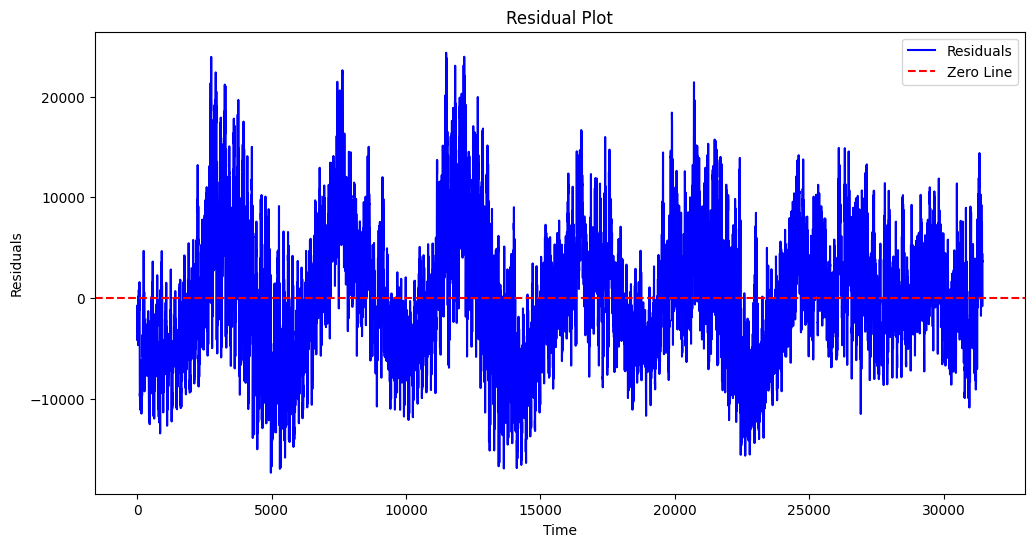

In [94]:
residuals = y_true_mw - y_hat_holiday

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Residual Plot')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.legend()
plt.show()

The residuals exhibit a **sinusoidal pattern** in the residual plot, it indicates that the model has not fully captured a recurring cyclical pattern in your data. This type of pattern suggests that the model failed to account for some periodic behavior, such as:

#### **1. Seasonality**
- The sinusoidal shape often points to **seasonal effects** (daily, weekly, monthly, etc.) that are present in the data but not captured by the model. 
- For example, in energy consumption data:
  - Peaks during daytime (high usage).
  - Troughs during nighttime (low usage).
  - Weekly cycles (weekend vs. weekday consumption).


#### **2. Periodic Trends**
- A sinusoidal residual may also signify an **unmodeled trend** with a regular pattern. This could occur if:
  - The seasonal period provided to the model was incorrect or incomplete.
  - The seasonality or trend was too complex for the model to capture (e.g., multi-seasonality, interactions).


#### **3. Overfitting/Underfitting**
- If the model is underfitting, it might not capture detailed patterns like higher-frequency cycles.
- If the model is overfitting, it may ignore broader seasonal trends and focus on noise.


#### **Steps to Address Sinusoidal Residuals**
**a. Add or Adjust Seasonality in Prophet**

Prophet can model seasonality explicitly. Consider:
1. **Add Custom Seasonalities**
   If the sinusoidal pattern represents a specific periodic cycle not captured by default:
   ```python
   model.add_seasonality(name='custom_cycle', period=12, fourier_order=3)
   ```
   Replace `period=12` with the length of the cycle observed (e.g., hours, days).

2. **Tune Default Seasonality Parameters**
   Prophet automatically models yearly, weekly, and daily seasonality, but the default settings may not fit your data. For instance:
   ```python
   model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
   ```



**b. Check Fourier Order**

The Fourier order determines how detailed the seasonal components are. If the order is too low, the seasonality won't be captured adequately:
```python
model.add_seasonality(name='weekly', period=7, fourier_order=10)
```


**c. Decompose Residuals**

Analyze the residuals for seasonal components to confirm the periodicity:
```python
from statsmodels.tsa.seasonal import seasonal_decompose

residual_decomp = seasonal_decompose(residuals, model='additive', period=24)  # Adjust period
residual_decomp.plot()
plt.show()
```
This will help identify the frequency of the sinusoidal pattern.


**d. Use Alternative Models**
If Prophet struggles with the sinusoidal pattern, you can:
1. **Hybrid Approach:** Combine Prophet with ARIMA or machine learning models to handle complex seasonality.
2. **Switch to ARIMA/SARIMA:** These are better at capturing periodic trends when seasonality is well-defined.


#### **Summary**
A sinusoidal residual indicates an unmodeled periodic effect (seasonality or trend). Adjust your Prophet model to capture the cycle:
- Add custom seasonality or adjust Fourier orders.
- Investigate the exact period of the sinusoidal pattern using decomposition or autocorrelation.

---

**b. Histogram of Residuals**
 - This helps verify if residuals follow a normal distribution. Non-normal residuals might indicate missed patterns.

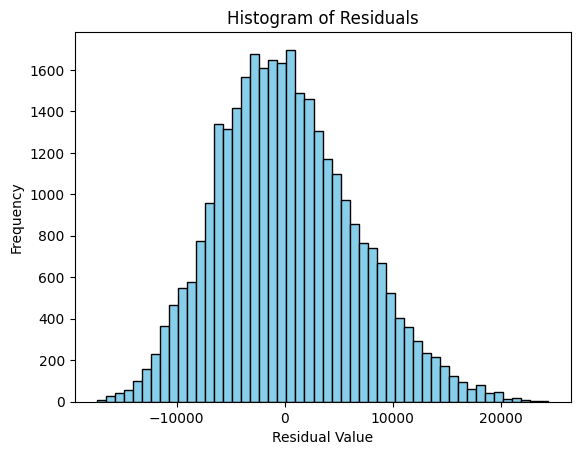

In [99]:
plt.hist(residuals, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

### 3. Check for Trends or Seasonality
**a. Autocorrelation in Residuals**
 - Use the Autocorrelation Function (ACF) to check if residuals are autocorrelated. Significant autocorrelation indicates that the model missed some structure in the data.

<Figure size 1000x500 with 0 Axes>

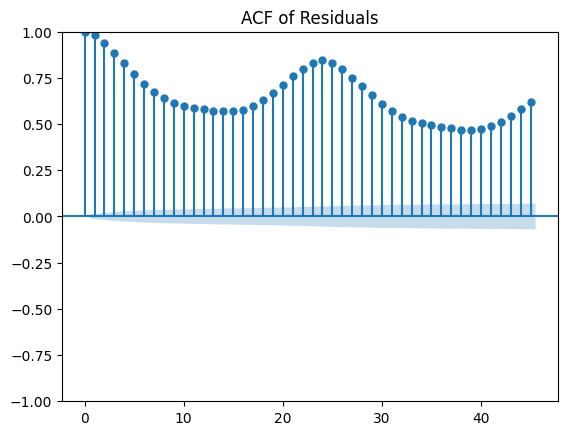

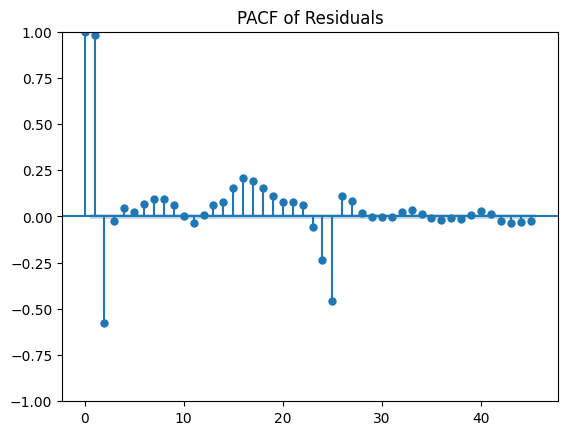

In [98]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,5))
plot_acf(residuals)
plt.title('ACF of Residuals')
plot_pacf(residuals)
plt.title('PACF of Residuals')
plt.show()

**b. Rolling Statistics**
 - Compute rolling mean and standard deviation of residuals to detect any remaining trends or shifts in variance:

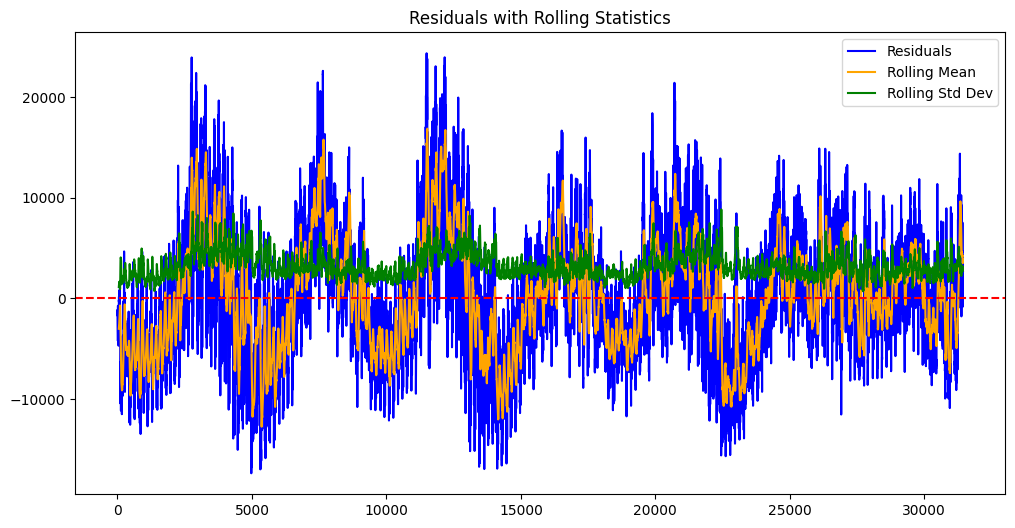

In [97]:
residuals_rolling_mean = residuals.rolling(window=50).mean()
residuals_rolling_std = residuals.rolling(window=50).std()

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.plot(residuals_rolling_mean, label='Rolling Mean', color='orange')
plt.plot(residuals_rolling_std, label='Rolling Std Dev', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals with Rolling Statistics')
plt.legend()
plt.show()

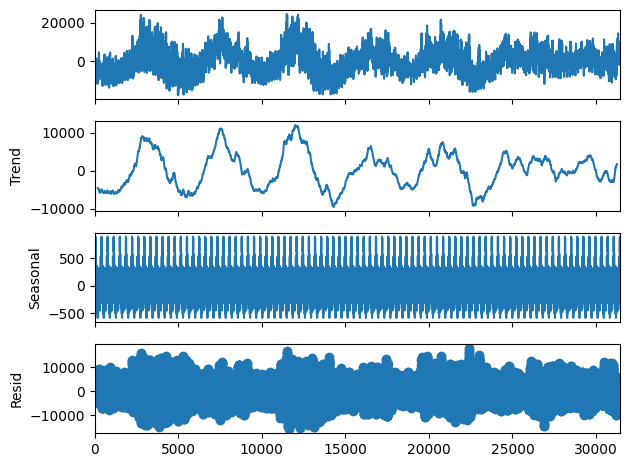

In [101]:
from statsmodels.tsa.seasonal import seasonal_decompose

residual_decomp = seasonal_decompose(residuals, model='additive', period=365)  # Adjust period
residual_decomp.plot()
plt.show()

| Platform     | Profile Link                                   |
|--------------|-----------------------------------------------|
| LinkedIn     | [Fawad Awan](https://linkedin.com/in//fawad-awan-893a58171) |
| GitHub       | [JackTheProgrammer](https://github.com/JackTheProgrammer)      |
